In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1773307771.921510    4791 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.experimental.list_physical_devices()

E0000 00:00:1773307775.658454    4791 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
tf.__version__

'2.21.0'

In [4]:
tf.test.is_built_with_cuda()

True

In [5]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()

In [6]:
X_train.shape

(50000, 32, 32, 3)

In [7]:
y_train.shape

(50000, 1)

In [8]:
def plot_sample(index):
    plt.figure(figsize=(10,1))
    plt.imshow(X_train[index])

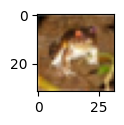

In [9]:
plot_sample(0)

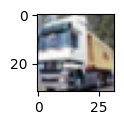

In [10]:
plot_sample(1)

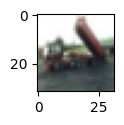

In [11]:
plot_sample(2)

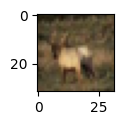

In [12]:
plot_sample(3)

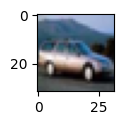

In [13]:
plot_sample(4)

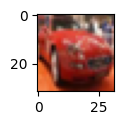

In [14]:
plot_sample(5)

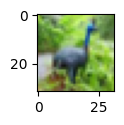

In [15]:
plot_sample(6)

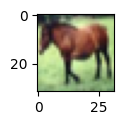

In [16]:
plot_sample(7)

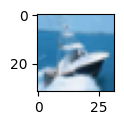

In [17]:
plot_sample(8)

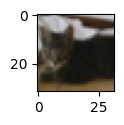

In [18]:
plot_sample(9)

In [19]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

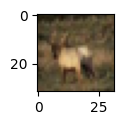

In [20]:
plot_sample(3)

In [21]:
classes[y_train[3][0]]

'deer'

In [23]:
y_train[:3]

array([[6],
       [9],
       [9]], dtype=uint8)

In [24]:
y_test.shape

(10000, 1)

In [25]:
X_train.shape

(50000, 32, 32, 3)

In [26]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [27]:
y_train_categorical=keras.utils.to_categorical(
    y_train,num_classes=10
)
y_test_categorical=keras.utils.to_categorical(
    y_test,num_classes=10
)

In [28]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [29]:
y_train_categorical[0:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])
model.compile(
    optimizer='SGD',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
model.fit(X_train_scaled,y_train_categorical,epochs=1)

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1773307810.905924    4791 cpu_allocator_impl.cc:82] Allocation of 36864000 exceeds 10% of free system memory.
W0000 00:00:1773307810.930838    4791 cpu_allocator_impl.cc:82] Allocation of 36864000 exceeds 10% of free system memory.
W0000 00:00:1773307810.943464    4791 cpu_allocator_impl.cc:82] Allocation of 36864000 exceeds 10% of free system memory.
W0000 00:00:1773307812.929159    4791 cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.


   2/1563 ━━━━━━━━━━━━━━━━━━━━ 2:19 89ms/step - accuracy: 0.1172 - loss: 2.5476  

W0000 00:00:1773307814.416110    4851 cpu_allocator_impl.cc:82] Allocation of 36864000 exceeds 10% of free system memory.


 403/1563 ━━━━━━━━━━━━━━━━━━━━ 1:17 67ms/step - accuracy: 0.2373 - loss: 2.0901

In [1]:
np.agrmax(model.predict(X_test_scaled)[0])

NameError: name 'np' is not defined

In [ ]:
y_test[0]

In [ ]:
def get_model():
    model=keras.Sequential([
        keras.layers.Flatten(input_shape=(32,32,3)),
        keras.layers.Dense(3000,activation='relu'),
        keras.layers.Dense(1000,activation='relu'),
        keras.layers.Dense(10,activation='sigmoid')
    ])
    model.compile(optimizer='SGD',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
    return model

In [ ]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    cpu_model=get_model()
    cpu_model.fit(X_train_scaled,y_train_categorical,epochs=1)

In [ ]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    cpu_model=get_model()
    cpu_model.fit(X_train_scaled,y_train_categorical,epochs=1)

In [ ]:
#let us run the same code for 10 epochs to see how much will cpu and gpu takes
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    cpu_model=get_model()
    cpu_model.fit(X_train_scaled,y_train_categorical,epochs=10)

In [ ]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    cpu_model=get_model()
    cpu_model.fit(X_train_scaled,y_train_categorical,epochs=10)